Q1: Differential-Drive Robot with Orientation-Dependent Planning

Defining the environment

In [16]:
import numpy as np

GRID_SIZE = 10
ORIENTATIONS = [0, 1, 2, 3]         #for east ,north ,west, south
ACTIONS = ["F", "L", "R"]

GAMMA = 0.95
STEP_REWARD = -1
GOAL_REWARD = 50
COLLISION_REWARD = -100
OBSTACLES = {(3, 3), (3, 4), (4, 4), (6, 6), (7, 2)}
GOAL = (9, 9)

COLLISION_STATE = "COLLISION"       #Terminal state 

DIRS = {
    0: ((1, 0), (0, 1), (0, -1)),   
    1: ((0, 1), (-1, 0), (1, 0)),   
    2: ((-1, 0), (0, -1), (0, 1)),
    3: ((0, -1), (1, 0), (-1, 0)),
}

states = []
for x in range(GRID_SIZE):
    for y in range(GRID_SIZE):
        if (x, y) not in OBSTACLES:
            for theta in ORIENTATIONS:
                states.append((x, y, theta))

states.append(COLLISION_STATE)

terminal_states = {COLLISION_STATE}
for theta in ORIENTATIONS:
    terminal_states.add((GOAL[0], GOAL[1], theta))



def is_valid(x, y):
    if x < 0 or x >= GRID_SIZE or y < 0 or y >= GRID_SIZE:
        return False
    if (x, y) in OBSTACLES:
        return False
    return True


def get_transitions(state, action):                 #it will returns list of (prob, nextstate, reward)
    if state in terminal_states:
        return []

    x, y, theta = state
    transitions = []

    if action == "L":
        next_state = (x, y, (theta + 1) % 4)
        transitions.append((1.0, next_state, STEP_REWARD))

    elif action == "R":
        next_state = (x, y, (theta - 1) % 4)
        transitions.append((1.0, next_state, STEP_REWARD))

    elif action == "F":
        forward, left, right = DIRS[theta]

        moves = [
            (0.8, forward),
            (0.1, left),
            (0.1, right)
        ]

        for prob, (dx, dy) in moves:
            nx, ny = x + dx, y + dy

            if not is_valid(nx, ny):
                transitions.append((prob, COLLISION_STATE, COLLISION_REWARD))
            elif (nx, ny) == GOAL:
                transitions.append((prob, (nx, ny, theta), GOAL_REWARD))
            else:
                transitions.append((prob, (nx, ny, theta), STEP_REWARD))

    return transitions

Value Iteration

In [17]:
V = {}
for s in states:
    V[s] = 0.0

NUM_ITERATIONS = 3

for k in range(NUM_ITERATIONS):
    V_new = V.copy()

    for s in states:
        if s in terminal_states:
            continue

        action_values = []

        for a in ACTIONS:
            val = 0
            for p, s_next, r in get_transitions(s, a):
                val += p * (r + GAMMA * V[s_next])
            action_values.append(val)

        V_new[s] = max(action_values)

    V = V_new

    print(f"\nValue Function after iteration {k+1}:")
    sample_states = [
        (0, 0, 0),              # normal state
        (3, 2, 1),              # near obstacle
        (8, 9, 1)               # near goal
    ]

    for ss in sample_states:
        if ss in V:
            print(f"V{ k+1 }{ss} = {V[ss]:.3f}")


# Extract optimal policy
v_policy = {}

for s in states:
    if s in terminal_states:
        continue

    best_action = None
    best_value = -float("inf")

    for a in ACTIONS:
        val = 0
        for p, s_next, r in get_transitions(s, a):
            val += p * (r + GAMMA * V[s_next])

        if val > best_value:
            best_value = val
            best_action = a

    v_policy[s] = best_action


print("\nSample optimal actions:")
for ss in sample_states:
    if ss in v_policy:
        print(f"pi({ss}) = {v_policy[ss]}")



Value Function after iteration 1:
V1(0, 0, 0) = -1.000
V1(3, 2, 1) = -1.000
V1(8, 9, 1) = -1.000

Value Function after iteration 2:
V2(0, 0, 0) = -1.950
V2(3, 2, 1) = -1.950
V2(8, 9, 1) = 27.405

Value Function after iteration 3:
V3(0, 0, 0) = -2.853
V3(3, 2, 1) = -2.853
V3(8, 9, 1) = 27.315

Sample optimal actions:
pi((0, 0, 0)) = L
pi((3, 2, 1)) = L
pi((8, 9, 1)) = R


In [18]:
import random

p_policy = {}
for s in states:
    if s not in terminal_states:
        p_policy[s] = random.choice(ACTIONS)


V = {s: 0.0 for s in states}

NUM_POLICY_ITERATIONS = 3

for k in range(NUM_POLICY_ITERATIONS):

    # Policy Evaluation
    V_new = V.copy()

    for s in states:
        if s in terminal_states:
            continue

        a = p_policy[s]
        value = 0.0
        for p, s_next, r in get_transitions(s, a):
            value += p * (r + GAMMA * V[s_next])

        V_new[s] = value

    V = V_new


    # Policy Improvement
    for s in states:
        if s in terminal_states:
            continue

        best_action = None
        best_value = -float("inf")

        for a in ACTIONS:
            value = 0.0
            for p, s_next, r in get_transitions(s, a):
                value += p * (r + GAMMA * V[s_next])

            if value > best_value:
                best_value = value
                best_action = a

        p_policy[s] = best_action




    print(f"\nPolicy Iteration {k+1}")
    sample_states = [
        (0, 0, 0),
        (3, 2, 1),
        (8, 9, 1)
    ]

    for ss in sample_states:
        if ss in p_policy:
            print(f"pi{ k+1 }({ss}) = {p_policy[ss]} | V = {V[ss]:.3f}")



Policy Iteration 1
pi1((0, 0, 0)) = L | V = -1.000
pi1((3, 2, 1)) = L | V = -80.200
pi1((8, 9, 1)) = R | V = -1.000

Policy Iteration 2
pi2((0, 0, 0)) = L | V = -1.950
pi2((3, 2, 1)) = L | V = -1.950
pi2((8, 9, 1)) = R | V = -1.950

Policy Iteration 3
pi3((0, 0, 0)) = L | V = -2.853
pi3((3, 2, 1)) = L | V = -2.853
pi3((8, 9, 1)) = R | V = 27.315


Value Iteration and Policy Iteration untill convergence for comparison

In [19]:
import time
import tracemalloc
def run_value_iteration(states, terminal_states, ACTIONS, GAMMA, get_transitions, tol=1e-4, max_iters=1000):

    V = {s: 0.0 for s in states}
    iterations = 0

    start_time = time.time()
    tracemalloc.start()

    for k in range(max_iters):
        delta = 0
        V_new = V.copy()

        for s in states:
            if s in terminal_states:
                continue

            best_val = -float("inf")

            for a in ACTIONS:
                val = 0
                for p, s_next, r in get_transitions(s, a):
                    val += p * (r + GAMMA * V[s_next])

                best_val = max(best_val, val)

            delta = max(delta, abs(best_val - V[s]))
            V_new[s] = best_val

        V = V_new
        iterations += 1

        if delta < tol:
            break

    # Extract optimal policy
    v_policy = {}
    for s in states:
        if s in terminal_states:
            continue

        best_action = None
        best_val = -float("inf")

        for a in ACTIONS:
            val = 0
            for p, s_next, r in get_transitions(s, a):
                val += p * (r + GAMMA * V[s_next])

            if val > best_val:
                best_val = val
                best_action = a

        v_policy[s] = best_action

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    return V, v_policy, iterations, runtime, peak


#Policy Iteration until convergence
import random

def run_policy_iteration(states, terminal_states, ACTIONS, GAMMA, get_transitions, tol=1e-4, max_iters=1000):

    p_policy = {s: random.choice(ACTIONS) for s in states if s not in terminal_states}
    V = {s: 0.0 for s in states}
    iterations = 0

    start_time = time.time()
    tracemalloc.start()

    for k in range(max_iters):

        # Policy Evaluation
        while True:
            delta = 0
            V_new = V.copy()

            for s in states:
                if s in terminal_states:
                    continue

                a = p_policy[s]
                val = 0
                for p, s_next, r in get_transitions(s, a):
                    val += p * (r + GAMMA * V[s_next])

                delta = max(delta, abs(val - V[s]))
                V_new[s] = val

            V = V_new

            if delta < tol:
                break


        # Policy Improvement
        policy_stable = True

        for s in states:
            if s in terminal_states:
                continue

            old_action = p_policy[s]
            best_action = None
            best_val = -float("inf")

            for a in ACTIONS:
                val = 0
                for p, s_next, r in get_transitions(s, a):
                    val += p * (r + GAMMA * V[s_next])

                if val > best_val:
                    best_val = val
                    best_action = a

            p_policy[s] = best_action

            if best_action != old_action:
                policy_stable = False

        iterations += 1

        if policy_stable:
            break

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    return V, p_policy, iterations, runtime, peak




V_vi, v_policy, vi_iters, vi_time, vi_mem = run_value_iteration(
    states, terminal_states, ACTIONS, GAMMA, get_transitions
)

V_pi, p_policy, pi_iters, pi_time, pi_mem = run_policy_iteration(
    states, terminal_states, ACTIONS, GAMMA, get_transitions
)

print("\n Comparison")
print(f"Value Iteration  -> Iterations: {vi_iters}, Runtime: {vi_time:.4f}s, Peak Memory: {vi_mem/1024:.2f} KB")
print(f"Policy Iteration -> Iterations: {pi_iters}, Runtime: {pi_time:.4f}s, Peak Memory: {pi_mem/1024:.2f} KB")



 Comparison
Value Iteration  -> Iterations: 95, Runtime: 0.3722s, Peak Memory: 55.27 KB
Policy Iteration -> Iterations: 10, Runtime: 1.2502s, Peak Memory: 53.48 KB


Plotting Orientation Aware Optimal Policy

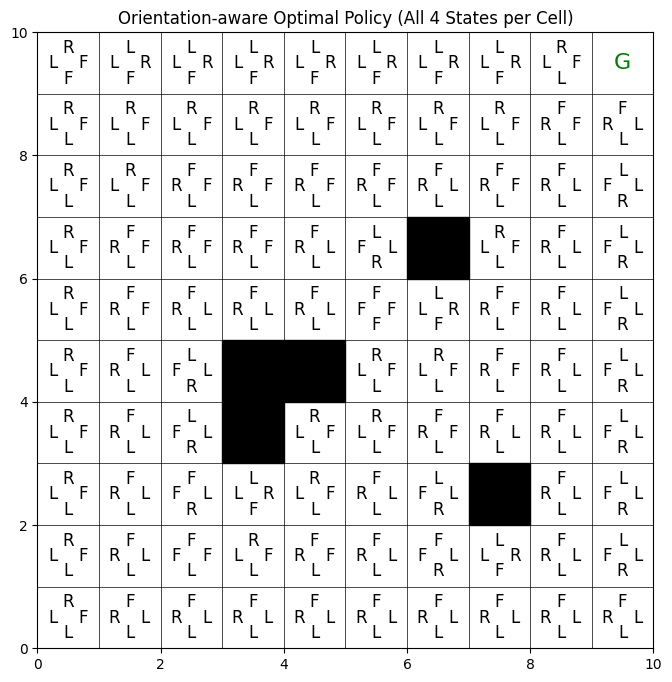

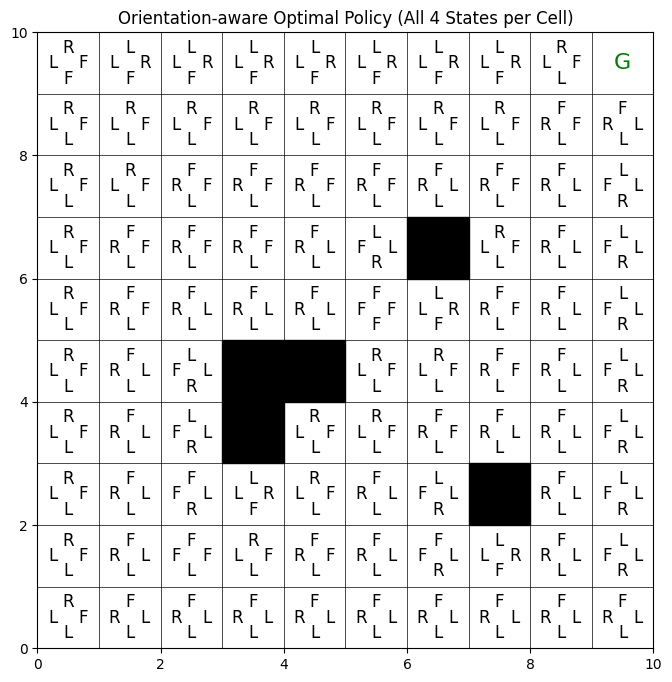

In [20]:
import matplotlib.pyplot as plt

OFFSET = {
    0: (0.25, 0),    # East
    1: (0, 0.25),    # North
    2: (-0.25, 0),   # West
    3: (0, -0.25)    # South
}

ARROWS = {
    (0, "F"): "F",
    (1, "F"): "F",
    (2, "F"): "F",
    (3, "F"): "F",
    (0, "L"): "L",
    (1, "L"): "L",
    (2, "L"): "L",
    (3, "L"): "L",
    (0, "R"): "R",
    (1, "R"): "R",
    (2, "R"): "R",
    (3, "R"): "R"
}


def visualize_full_policy(policy):

    plt.figure(figsize=(8,8))
    plt.title("Orientation-aware Optimal Policy (All 4 States per Cell)")

    for x in range(GRID_SIZE+1):
        plt.plot([x, x], [0, GRID_SIZE], color='black', linewidth=0.5)
    for y in range(GRID_SIZE+1):
        plt.plot([0, GRID_SIZE], [y, y], color='black', linewidth=0.5)

    for (ox, oy) in OBSTACLES:
        plt.fill_between([ox, ox+1], oy, oy+1, color='black')

    gx, gy = GOAL
    plt.text(gx+0.5, gy+0.5, "G", ha='center', va='center', fontsize=16, color='green')

    for s, a in policy.items():
        if s == COLLISION_STATE:
            continue

        x, y, theta = s

        if (x, y) == GOAL:
            continue

        dx, dy = OFFSET[theta]
        arrow = ARROWS[(theta, a)]

        plt.text(x+0.5+dx, y+0.5+dy,
                 arrow, ha='center', va='center', fontsize=12)

    plt.xlim(0, GRID_SIZE)
    plt.ylim(0, GRID_SIZE)
    plt.gca().set_aspect('equal')
    plt.show()

visualize_full_policy(v_policy)
visualize_full_policy(p_policy)

Changing reward values to :-  

STEP_REWARD = -1  
GOAL_REWARD = 50         
COLLISION_REWARD = -10  ---------- low collison reward


In [21]:
import numpy as np

GRID_SIZE = 10
ORIENTATIONS = [0, 1, 2, 3]         #for east ,north ,west, south
ACTIONS = ["F", "L", "R"]

GAMMA = 0.95
STEP_REWARD = -1
GOAL_REWARD = 50
COLLISION_REWARD = -10
OBSTACLES = {(3, 3), (3, 4), (4, 4), (6, 6), (7, 2)}
GOAL = (9, 9)

COLLISION_STATE = "COLLISION"       #Terminal state 

DIRS = {
    0: ((1, 0), (0, 1), (0, -1)),   
    1: ((0, 1), (-1, 0), (1, 0)),   
    2: ((-1, 0), (0, -1), (0, 1)),
    3: ((0, -1), (1, 0), (-1, 0)),
}

states = []
for x in range(GRID_SIZE):
    for y in range(GRID_SIZE):
        if (x, y) not in OBSTACLES:
            for theta in ORIENTATIONS:
                states.append((x, y, theta))

states.append(COLLISION_STATE)

terminal_states = {COLLISION_STATE}
for theta in ORIENTATIONS:
    terminal_states.add((GOAL[0], GOAL[1], theta))



def is_valid(x, y):
    if x < 0 or x >= GRID_SIZE or y < 0 or y >= GRID_SIZE:
        return False
    if (x, y) in OBSTACLES:
        return False
    return True


def get_transitions(state, action):                 #it will returns list of (prob, nextstate, reward)
    if state in terminal_states:
        return []

    x, y, theta = state
    transitions = []

    if action == "L":
        next_state = (x, y, (theta + 1) % 4)
        transitions.append((1.0, next_state, STEP_REWARD))

    elif action == "R":
        next_state = (x, y, (theta - 1) % 4)
        transitions.append((1.0, next_state, STEP_REWARD))

    elif action == "F":
        forward, left, right = DIRS[theta]

        moves = [
            (0.8, forward),
            (0.1, left),
            (0.1, right)
        ]

        for prob, (dx, dy) in moves:
            nx, ny = x + dx, y + dy

            if not is_valid(nx, ny):
                transitions.append((prob, COLLISION_STATE, COLLISION_REWARD))
            elif (nx, ny) == GOAL:
                transitions.append((prob, (nx, ny, theta), GOAL_REWARD))
            else:
                transitions.append((prob, (nx, ny, theta), STEP_REWARD))

    return transitions

In [22]:
import time
import tracemalloc

#Value Iteration until convergence
def run_value_iteration(states, terminal_states, ACTIONS, GAMMA, get_transitions, tol=1e-4, max_iters=1000):

    V = {s: 0.0 for s in states}
    iterations = 0

    start_time = time.time()
    tracemalloc.start()

    for k in range(max_iters):
        delta = 0
        V_new = V.copy()

        for s in states:
            if s in terminal_states:
                continue

            best_val = -float("inf")

            for a in ACTIONS:
                val = 0
                for p, s_next, r in get_transitions(s, a):
                    val += p * (r + GAMMA * V[s_next])

                best_val = max(best_val, val)

            delta = max(delta, abs(best_val - V[s]))
            V_new[s] = best_val

        V = V_new
        iterations += 1

        if delta < tol:
            break

    # Extract optimal policy
    v_policy = {}
    for s in states:
        if s in terminal_states:
            continue

        best_action = None
        best_val = -float("inf")

        for a in ACTIONS:
            val = 0
            for p, s_next, r in get_transitions(s, a):
                val += p * (r + GAMMA * V[s_next])

            if val > best_val:
                best_val = val
                best_action = a

        v_policy[s] = best_action

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    return V, v_policy, iterations, runtime, peak


#Policy Iteration until convergence
import random

def run_policy_iteration(states, terminal_states, ACTIONS, GAMMA, get_transitions, tol=1e-4, max_iters=1000):

    p_policy = {s: random.choice(ACTIONS) for s in states if s not in terminal_states}
    V = {s: 0.0 for s in states}
    iterations = 0

    start_time = time.time()
    tracemalloc.start()

    for k in range(max_iters):

        # Policy Evaluation
        while True:
            delta = 0
            V_new = V.copy()

            for s in states:
                if s in terminal_states:
                    continue

                a = p_policy[s]
                val = 0
                for p, s_next, r in get_transitions(s, a):
                    val += p * (r + GAMMA * V[s_next])

                delta = max(delta, abs(val - V[s]))
                V_new[s] = val

            V = V_new

            if delta < tol:
                break


        # Policy Improvement
        policy_stable = True

        for s in states:
            if s in terminal_states:
                continue

            old_action = p_policy[s]
            best_action = None
            best_val = -float("inf")

            for a in ACTIONS:
                val = 0
                for p, s_next, r in get_transitions(s, a):
                    val += p * (r + GAMMA * V[s_next])

                if val > best_val:
                    best_val = val
                    best_action = a

            p_policy[s] = best_action

            if best_action != old_action:
                policy_stable = False

        iterations += 1

        if policy_stable:
            break

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    return V, p_policy, iterations, runtime, peak




V_vi, v_policy, vi2_iters, vi2_time, vi2_mem = run_value_iteration(
    states, terminal_states, ACTIONS, GAMMA, get_transitions
)

V_pi, p_policy, pi2_iters, pi2_time, pi2_mem = run_policy_iteration(
    states, terminal_states, ACTIONS, GAMMA, get_transitions
)

print("\n Comparison")
print(f"Value Iteration  -> Iterations: {vi2_iters}, Runtime: {vi2_time:.4f}s, Peak Memory: {vi2_mem/1024:.2f} KB")
print(f"Policy Iteration -> Iterations: {pi2_iters}, Runtime: {pi2_time:.4f}s, Peak Memory: {pi2_mem/1024:.2f} KB")



 Comparison
Value Iteration  -> Iterations: 52, Runtime: 0.2248s, Peak Memory: 58.15 KB
Policy Iteration -> Iterations: 9, Runtime: 0.6537s, Peak Memory: 53.22 KB


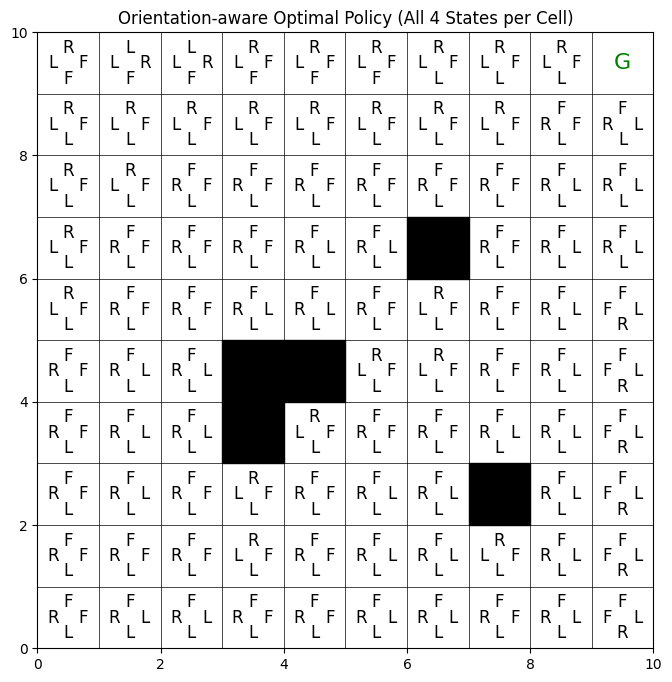

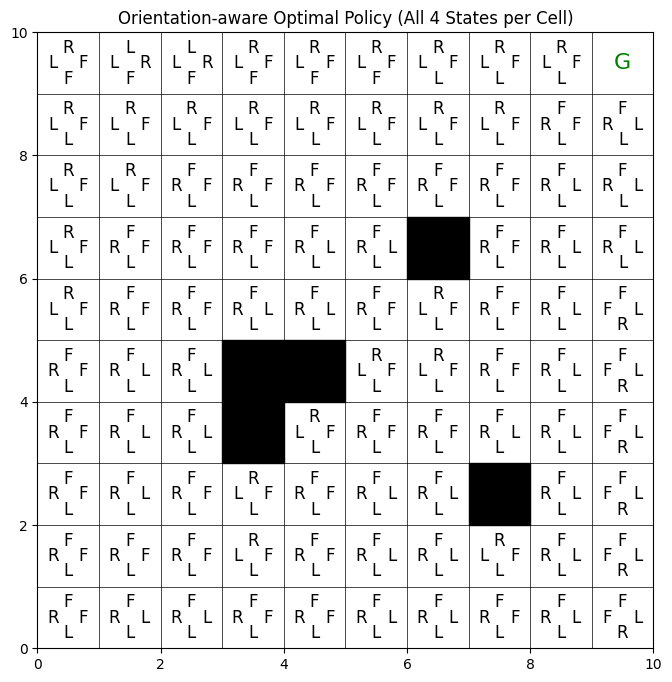

In [23]:
import matplotlib.pyplot as plt

# Orientation placement inside each cell
OFFSET = {
    0: (0.25, 0),    # East
    1: (0, 0.25),    # North
    2: (-0.25, 0),   # West
    3: (0, -0.25)    # South
}

ARROWS = {
    (0, "F"): "F",
    (1, "F"): "F",
    (2, "F"): "F",
    (3, "F"): "F",
    (0, "L"): "L",
    (1, "L"): "L",
    (2, "L"): "L",
    (3, "L"): "L",
    (0, "R"): "R",
    (1, "R"): "R",
    (2, "R"): "R",
    (3, "R"): "R"
}


def visualize_full_policy(policy):

    plt.figure(figsize=(8,8))
    plt.title("Orientation-aware Optimal Policy (All 4 States per Cell)")


    for x in range(GRID_SIZE+1):
        plt.plot([x, x], [0, GRID_SIZE], color='black', linewidth=0.5)
    for y in range(GRID_SIZE+1):
        plt.plot([0, GRID_SIZE], [y, y], color='black', linewidth=0.5)

   
    for (ox, oy) in OBSTACLES:
        plt.fill_between([ox, ox+1], oy, oy+1, color='black')

   
    gx, gy = GOAL
    plt.text(gx+0.5, gy+0.5, "G", ha='center', va='center', fontsize=16, color='green')


    for s, a in policy.items():
        if s == COLLISION_STATE:
            continue

        x, y, theta = s

        if (x, y) == GOAL:
            continue

        dx, dy = OFFSET[theta]
        arrow = ARROWS[(theta, a)]

        plt.text(x+0.5+dx, y+0.5+dy,
                 arrow, ha='center', va='center', fontsize=12)

    plt.xlim(0, GRID_SIZE)
    plt.ylim(0, GRID_SIZE)
    plt.gca().set_aspect('equal')
    plt.show()



visualize_full_policy(v_policy)
visualize_full_policy(p_policy)

Changing reward values to :-  

STEP_REWARD = -15  ---------- high step penalty  
GOAL_REWARD = 50         
COLLISION_REWARD = -100   


In [24]:
import numpy as np

GRID_SIZE = 10
ORIENTATIONS = [0, 1, 2, 3]         #for east ,north ,west, south
ACTIONS = ["F", "L", "R"]

GAMMA = 0.95
STEP_REWARD = -15
GOAL_REWARD = 50
COLLISION_REWARD = -100
OBSTACLES = {(3, 3), (3, 4), (4, 4), (6, 6), (7, 2)}
GOAL = (9, 9)

COLLISION_STATE = "COLLISION"       #Terminal state 

DIRS = {
    0: ((1, 0), (0, 1), (0, -1)),   
    1: ((0, 1), (-1, 0), (1, 0)),   
    2: ((-1, 0), (0, -1), (0, 1)),
    3: ((0, -1), (1, 0), (-1, 0)),
}

states = []
for x in range(GRID_SIZE):
    for y in range(GRID_SIZE):
        if (x, y) not in OBSTACLES:
            for theta in ORIENTATIONS:
                states.append((x, y, theta))

states.append(COLLISION_STATE)

terminal_states = {COLLISION_STATE}
for theta in ORIENTATIONS:
    terminal_states.add((GOAL[0], GOAL[1], theta))



def is_valid(x, y):
    if x < 0 or x >= GRID_SIZE or y < 0 or y >= GRID_SIZE:
        return False
    if (x, y) in OBSTACLES:
        return False
    return True


def get_transitions(state, action):                 #it will returns list of (prob, nextstate, reward)
    if state in terminal_states:
        return []

    x, y, theta = state
    transitions = []

    if action == "L":
        next_state = (x, y, (theta + 1) % 4)
        transitions.append((1.0, next_state, STEP_REWARD))

    elif action == "R":
        next_state = (x, y, (theta - 1) % 4)
        transitions.append((1.0, next_state, STEP_REWARD))

    elif action == "F":
        forward, left, right = DIRS[theta]

        moves = [
            (0.8, forward),
            (0.1, left),
            (0.1, right)
        ]

        for prob, (dx, dy) in moves:
            nx, ny = x + dx, y + dy

            if not is_valid(nx, ny):
                transitions.append((prob, COLLISION_STATE, COLLISION_REWARD))
            elif (nx, ny) == GOAL:
                transitions.append((prob, (nx, ny, theta), GOAL_REWARD))
            else:
                transitions.append((prob, (nx, ny, theta), STEP_REWARD))

    return transitions

In [25]:
import time
import tracemalloc

#Value Iteration until convergence

def run_value_iteration(states, terminal_states, ACTIONS, GAMMA, get_transitions, tol=1e-4, max_iters=1000):

    V = {s: 0.0 for s in states}
    iterations = 0

    start_time = time.time()
    tracemalloc.start()

    for k in range(max_iters):
        delta = 0
        V_new = V.copy()

        for s in states:
            if s in terminal_states:
                continue

            best_val = -float("inf")

            for a in ACTIONS:
                val = 0
                for p, s_next, r in get_transitions(s, a):
                    val += p * (r + GAMMA * V[s_next])

                best_val = max(best_val, val)

            delta = max(delta, abs(best_val - V[s]))
            V_new[s] = best_val

        V = V_new
        iterations += 1

        if delta < tol:
            break

    # Extract optimal policy
    v_policy = {}
    for s in states:
        if s in terminal_states:
            continue

        best_action = None
        best_val = -float("inf")

        for a in ACTIONS:
            val = 0
            for p, s_next, r in get_transitions(s, a):
                val += p * (r + GAMMA * V[s_next])

            if val > best_val:
                best_val = val
                best_action = a

        v_policy[s] = best_action

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    return V, v_policy, iterations, runtime, peak


#Policy Iteration until convergence

import random

def run_policy_iteration(states, terminal_states, ACTIONS, GAMMA, get_transitions, tol=1e-4, max_iters=1000):

    p_policy = {s: random.choice(ACTIONS) for s in states if s not in terminal_states}
    V = {s: 0.0 for s in states}
    iterations = 0

    start_time = time.time()
    tracemalloc.start()

    for k in range(max_iters):

        # Policy Evaluation
        while True:
            delta = 0
            V_new = V.copy()

            for s in states:
                if s in terminal_states:
                    continue

                a = p_policy[s]
                val = 0
                for p, s_next, r in get_transitions(s, a):
                    val += p * (r + GAMMA * V[s_next])

                delta = max(delta, abs(val - V[s]))
                V_new[s] = val

            V = V_new

            if delta < tol:
                break


        # Policy Improvement
        policy_stable = True

        for s in states:
            if s in terminal_states:
                continue

            old_action = p_policy[s]
            best_action = None
            best_val = -float("inf")

            for a in ACTIONS:
                val = 0
                for p, s_next, r in get_transitions(s, a):
                    val += p * (r + GAMMA * V[s_next])

                if val > best_val:
                    best_val = val
                    best_action = a

            p_policy[s] = best_action

            if best_action != old_action:
                policy_stable = False

        iterations += 1

        if policy_stable:
            break

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    return V, p_policy, iterations, runtime, peak




V_vi, v_policy, vi3_iters, vi3_time, vi3_mem = run_value_iteration(
    states, terminal_states, ACTIONS, GAMMA, get_transitions
)

V_pi, p_policy, pi3_iters, pi3_time, pi3_mem = run_policy_iteration(
    states, terminal_states, ACTIONS, GAMMA, get_transitions
)

print("\n Comparison")
print(f"Value Iteration  -> Iterations: {vi3_iters}, Runtime: {vi3_time:.4f}s, Peak Memory: {vi3_mem/1024:.2f} KB")
print(f"Policy Iteration -> Iterations: {pi3_iters}, Runtime: {pi3_time:.4f}s, Peak Memory: {pi3_mem/1024:.2f} KB")



 Comparison
Value Iteration  -> Iterations: 30, Runtime: 0.1332s, Peak Memory: 58.24 KB
Policy Iteration -> Iterations: 10, Runtime: 0.6598s, Peak Memory: 53.85 KB


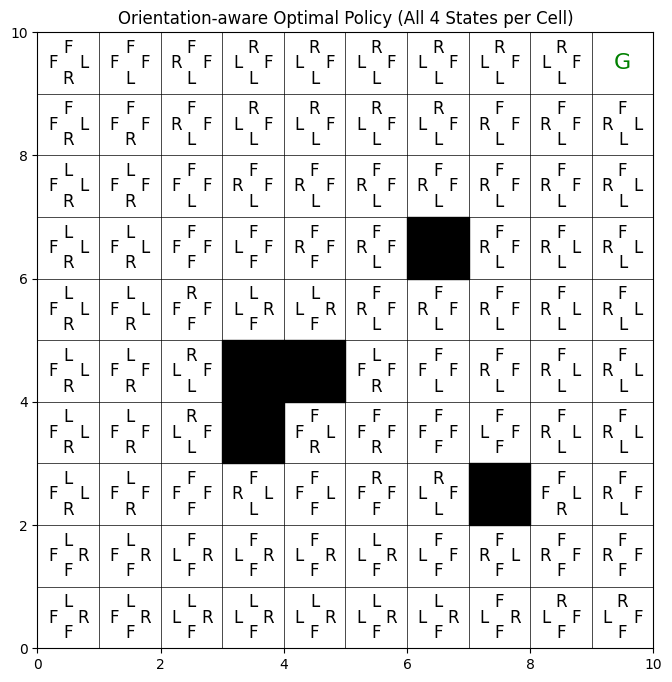

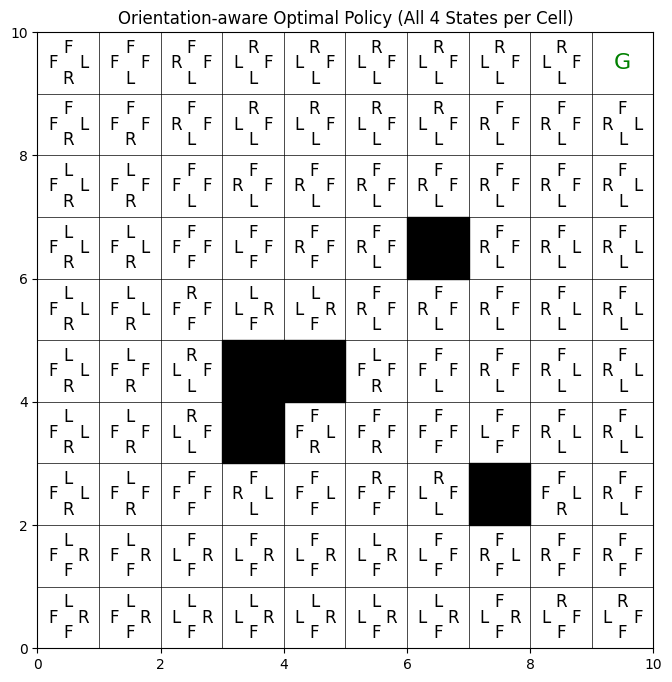

In [26]:
import matplotlib.pyplot as plt

# Orientation placement inside each cell
OFFSET = {
    0: (0.25, 0),    # East
    1: (0, 0.25),    # North
    2: (-0.25, 0),   # West
    3: (0, -0.25)    # South
}

ARROWS = {
    (0, "F"): "F",
    (1, "F"): "F",
    (2, "F"): "F",
    (3, "F"): "F",
    (0, "L"): "L",
    (1, "L"): "L",
    (2, "L"): "L",
    (3, "L"): "L",
    (0, "R"): "R",
    (1, "R"): "R",
    (2, "R"): "R",
    (3, "R"): "R"
}


def visualize_full_policy(policy):

    plt.figure(figsize=(8,8))
    plt.title("Orientation-aware Optimal Policy (All 4 States per Cell)")

   
    for x in range(GRID_SIZE+1):
        plt.plot([x, x], [0, GRID_SIZE], color='black', linewidth=0.5)
    for y in range(GRID_SIZE+1):
        plt.plot([0, GRID_SIZE], [y, y], color='black', linewidth=0.5)

 
    for (ox, oy) in OBSTACLES:
        plt.fill_between([ox, ox+1], oy, oy+1, color='black')

    gx, gy = GOAL
    plt.text(gx+0.5, gy+0.5, "G", ha='center', va='center', fontsize=16, color='green')


    for s, a in policy.items():
        if s == COLLISION_STATE:
            continue

        x, y, theta = s

        if (x, y) == GOAL:
            continue

        dx, dy = OFFSET[theta]
        arrow = ARROWS[(theta, a)]

        plt.text(x+0.5+dx, y+0.5+dy,
                 arrow, ha='center', va='center', fontsize=12)

    plt.xlim(0, GRID_SIZE)
    plt.ylim(0, GRID_SIZE)
    plt.gca().set_aspect('equal')
    plt.show()


visualize_full_policy(v_policy)
visualize_full_policy(p_policy)

In [27]:
import pandas as pd

vi_df = pd.DataFrame({
    "Reward1": [vi_iters, vi_time, vi_mem/1024],
    "Reward2": [vi2_iters, vi2_time, vi2_mem/1024],
    "Reward3": [vi3_iters, vi3_time, vi3_mem/1024]
},
index=["Iterations", "Runtime (s)", "Memory (KB)"])

print("\n Value Iteration")
display(vi_df)


pi_df = pd.DataFrame({
    "Reward1": [pi_iters, pi_time, pi_mem/1024],
    "Reward2": [pi2_iters, pi2_time, pi2_mem/1024],
    "Reward3": [pi3_iters, pi3_time, pi3_mem/1024]
},
index=["Iterations", "Runtime (s)", "Memory (KB)"])

print("\nPolicy Iteration")
display(pi_df)



 Value Iteration


,Reward1,Reward2,Reward3
Iterations,95.000000,52.000000,30.000000
Runtime (s),0.372177,0.224759,0.133172
Memory (KB),55.267578,58.154297,58.237305



Policy Iteration


,Reward1,Reward2,Reward3
Iterations,10.000000,9.000000,10.000000
Runtime (s),1.250162,0.653686,0.659817
Memory (KB),53.476562,53.218750,53.854492


Monte Carlo

In [28]:
import random

def run_monte_carlo(states, terminal_states, ACTIONS, GAMMA, get_transitions,
                    num_episodes=5000, epsilon=0.1):

  
    Q = {}
    returns_count = {}

    for s in states:
        if s not in terminal_states:
            Q[s] = {a: 0.0 for a in ACTIONS}
            returns_count[s] = {a: 0 for a in ACTIONS}

 
    mc_policy = {s: random.choice(ACTIONS)                              #random policy
                 for s in states if s not in terminal_states}

    start_time = time.time()
    tracemalloc.start()

    for episode in range(num_episodes):

        

        state = random.choice([s for s in states if s not in terminal_states])
        episode_data = []

        while state not in terminal_states:

            if random.random() < epsilon:                # epsilon-greedy 
                action = random.choice(ACTIONS)
            else:
                action = mc_policy[state]

            transitions = get_transitions(state, action)

            if not transitions:
                break


            probs = [t[0] for t in transitions]
            next_state, reward = random.choices(
                [(t[1], t[2]) for t in transitions],
                weights=probs
            )[0]

            episode_data.append((state, action, reward))
            state = next_state



        G = 0
        visited = set()

        for t in reversed(range(len(episode_data))):
            s, a, r = episode_data[t]
            G = GAMMA * G + r

            if (s, a) not in visited:
                visited.add((s, a))

                returns_count[s][a] += 1
                Q[s][a] += (G - Q[s][a]) / returns_count[s][a]

                # Policy Improvement
                best_action = max(Q[s], key=Q[s].get)
                mc_policy[s] = best_action

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    return Q, mc_policy, runtime, peak


Q_mc, mc_policy, mc_time, mc_mem = run_monte_carlo(
    states, terminal_states, ACTIONS, GAMMA, get_transitions
)

print("\nMonte Carlo Results")
print(f"Runtime: {mc_time:.4f}s")
print(f"Peak Memory: {mc_mem/1024:.2f} KB")



Monte Carlo Results
Runtime: 0.6618s
Peak Memory: 148.71 KB


In [29]:
print("\n=== Final Comparison ===")
print(f"Value Iteration  -> Iterations: {vi_iters}, Runtime: {vi_time:.4f}s")
print(f"Policy Iteration -> Iterations: {pi_iters}, Runtime: {pi_time:.4f}s")
print(f"Monte Carlo      -> Episodes: 5000, Runtime: {mc_time:.4f}s")


=== Final Comparison ===
Value Iteration  -> Iterations: 95, Runtime: 0.3722s
Policy Iteration -> Iterations: 10, Runtime: 1.2502s
Monte Carlo      -> Episodes: 5000, Runtime: 0.6618s
